# 003 — EIA Weekly Natural Gas Storage

**Source:** EIA API series `NG.NW2_EPG0_SWO_R48_BCF.W` via EIA API v2  
**File:** `data/raw/eia_storage_weekly.csv`  
**Units:** Billion cubic feet (Bcf)  
**Frequency:** Weekly (Thursday, reporting prior week)  
**Coverage:** 2010-01-01 to present

**Goal:** Understand the storage cycle — the injection/withdrawal pattern, the 5-year average comparison that the market uses as its compass, and what surplus/deficit storage looks like historically. Storage is the single most market-moving weekly data release in US natural gas.

In [3]:
from pathlib import Path

# Auto-detect repository root from current working directory.
project_root = Path.cwd().resolve()
if not (project_root / "data" / "raw").exists():
    for parent in [project_root, *project_root.parents]:
        if (parent / "data" / "raw").exists() and (parent / "notebooks").exists():
            project_root = parent
            break

print("Project root:", project_root)

Project root: C:\Users\alexd\Desktop\GIC\Prep\NatGasModel_US


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme(context="paper", font_scale=2.0, style="whitegrid")

DIAG = project_root / "diagram" / "003_eia_storage" #neater
DIAG.mkdir(parents=True, exist_ok=True)

## 1. Load & Inspect

In [5]:
df = pd.read_csv(project_root / "data" / "raw" / "eia_storage_weekly.csv", index_col="date", parse_dates=True)
storage = df["storage_bcf"].astype(float)

print(f"Date range:   {storage.index.min().date()} → {storage.index.max().date()}")
print(f"Observations: {len(storage):,}")
print(f"Missing:      {storage.isna().sum()}")

Date range:   2010-01-01 → 2026-03-20
Observations: 847
Missing:      0


In [6]:
storage.to_frame().sample(5).sort_index()

,storage_bcf
date,
2017-07-21,2980.0
2018-05-04,1432.0
2021-01-15,3009.0
2023-12-22,3490.0
2025-11-14,3946.0


In [7]:
storage.describe().round(0)

count     847.0
mean     2765.0
std       741.0
min       824.0
25%      2217.0
50%      2820.0
75%      3361.0
max      4047.0
Name: storage_bcf, dtype: float64

## 2. Full Storage History

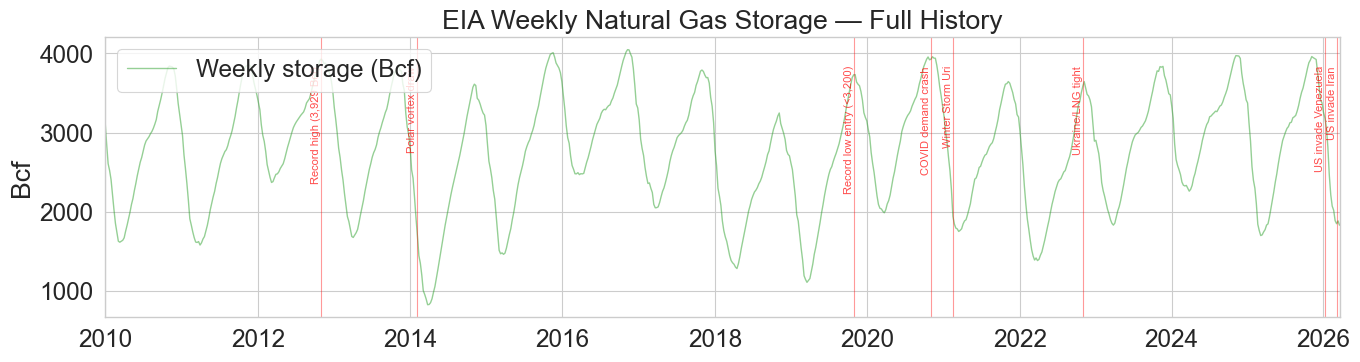

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))

storage.plot(ax=ax, color="tab:green", alpha=0.5, linewidth=1.0, label="Weekly storage (Bcf)")

events = {
    "2012-11-01": "Record high (3,929 Bcf)",
    "2014-02-01": "Polar vortex draw",
    "2019-11-01": "Record low entry (<3,200)",
    "2020-11-01": "COVID demand crash",
    "2021-02-15": "Winter Storm Uri",
    "2022-11-01": "Ukraine/LNG tight",
    "2026-01-03": "US invade Venezuela",
    "2026-02-28": "US invade Iran",
}

for date, label in events.items():
    ax.axvline(pd.Timestamp(date), color="red", alpha=0.4, linewidth=0.8)
    ax.annotate(
        label,
        xy=(pd.Timestamp(date), storage.max() * 0.95),
        fontsize=8,
        rotation=90,
        va="top",
        ha="right",
        color="red",
        alpha=0.7,
    )

ax.set_title("EIA Weekly Natural Gas Storage — Full History")
ax.set_ylabel("Bcf")
ax.set_xlabel("")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(DIAG / "storage_full_history.svg", format="svg", bbox_inches="tight")
plt.show()

## 3. Recent Period — 2020 to Present

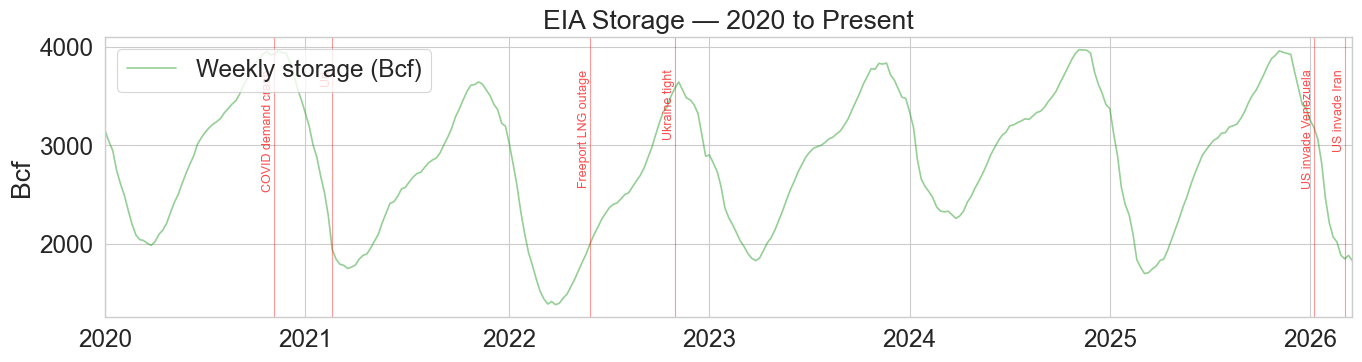

In [9]:
recent = storage["2020":]

fig, ax = plt.subplots(figsize=(14, 4))

recent.plot(ax=ax, color="tab:green", alpha=0.5, linewidth=1.2, label="Weekly storage (Bcf)")

recent_events = {
    "2020-11-01": "COVID demand crash",
    "2021-02-15": "Uri",
    "2022-06-01": "Freeport LNG outage",
    "2022-11-01": "Ukraine tight",
    "2026-01-03": "US invade Venezuela",
    "2026-02-28": "US invade Iran",
}

for date, label in recent_events.items():
    ax.axvline(pd.Timestamp(date), color="red", alpha=0.4, linewidth=0.8)
    ax.annotate(
        label,
        xy=(pd.Timestamp(date), recent.max() * 0.95),
        fontsize=9,
        rotation=90,
        va="top",
        ha="right",
        color="red",
        alpha=0.7,
    )

ax.set_title("EIA Storage — 2020 to Present")
ax.set_ylabel("Bcf")
ax.set_xlabel("")
ax.legend(loc="upper left")

fig.tight_layout()
fig.savefig(DIAG / "storage_recent_2020.svg", format="svg", bbox_inches="tight")
plt.show()

## 4. Seasonal Cycle — Injection vs Withdrawal

The weekly storage change (injection when positive, withdrawal when negative) reveals the injection season (April–October) vs withdrawal season (November–March). This is the heartbeat of the US gas market.

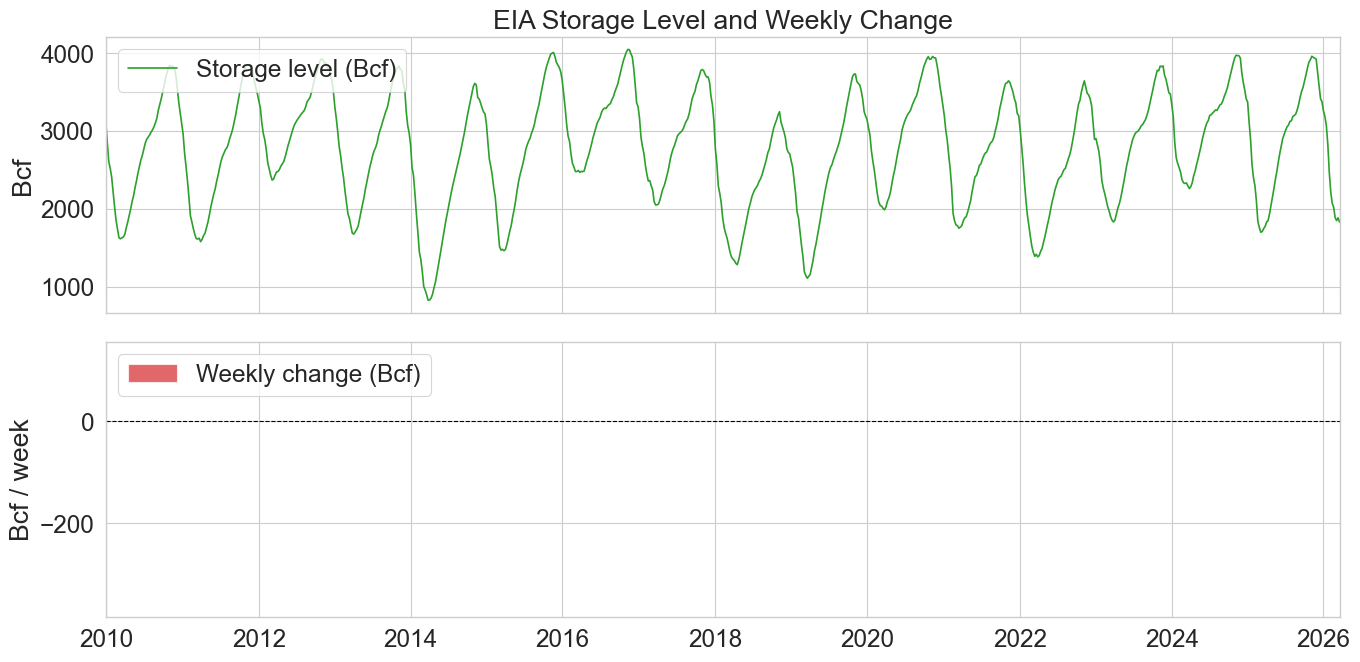

In [10]:
# Week-on-week change
storage_change = storage.diff()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

storage.plot(ax=axes[0], color="tab:green", linewidth=1.2, label="Storage level (Bcf)")
axes[0].set_ylabel("Bcf")
axes[0].set_title("EIA Storage Level and Weekly Change")
axes[0].legend(loc="upper left")

# Colour injections green, withdrawals red
axes[1].bar(
    storage_change.index,
    storage_change.values,
    color=np.where(storage_change >= 0, "tab:green", "tab:red"),
    alpha=0.7,
    width=5,
    label="Weekly change (Bcf)",
)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("Bcf / week")
axes[1].set_xlabel("")
axes[1].legend(loc="upper left")

fig.tight_layout()
fig.savefig(DIAG / "storage_injection_withdrawal.svg", format="svg", bbox_inches="tight")
plt.show()

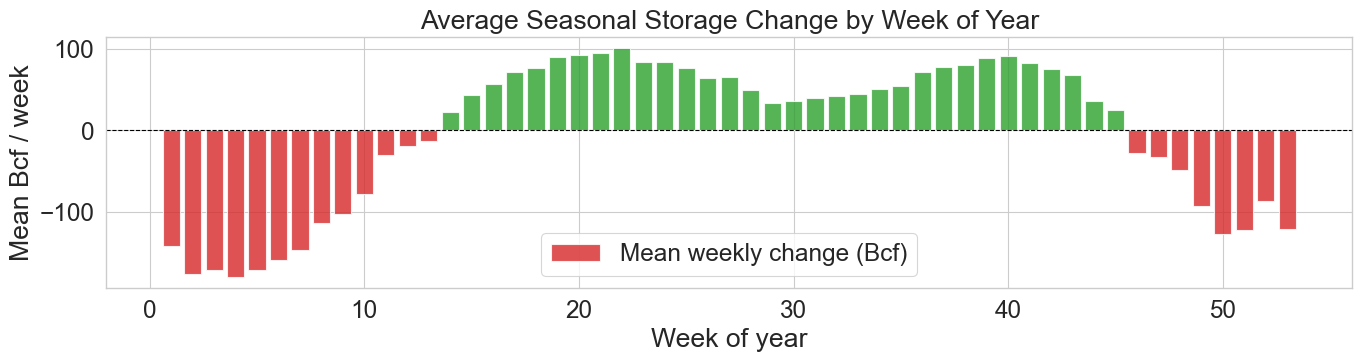

In [11]:
# Average seasonal profile — mean weekly change by week-of-year
storage_change_df = storage_change.to_frame(name="change_bcf")
storage_change_df["week"] = storage_change_df.index.isocalendar().week.astype(int)

seasonal = storage_change_df.groupby("week")["change_bcf"].mean()

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(
    seasonal.index,
    seasonal.values,
    color=np.where(seasonal >= 0, "tab:green", "tab:red"),
    alpha=0.8,
    label="Mean weekly change (Bcf)",
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Average Seasonal Storage Change by Week of Year")
ax.set_xlabel("Week of year")
ax.set_ylabel("Mean Bcf / week")
ax.legend()

fig.tight_layout()
fig.savefig(DIAG / "storage_seasonal_profile.svg", format="svg", bbox_inches="tight")
plt.show()

## 5. Storage Surplus / Deficit vs 5-Year Average

The market's primary compass: the gap between current storage and the 5-year average for the same week. A positive surplus (above-average storage) is bearish; a deficit is bullish. This is the metric reported every Thursday at 10:30am ET alongside the EIA release.

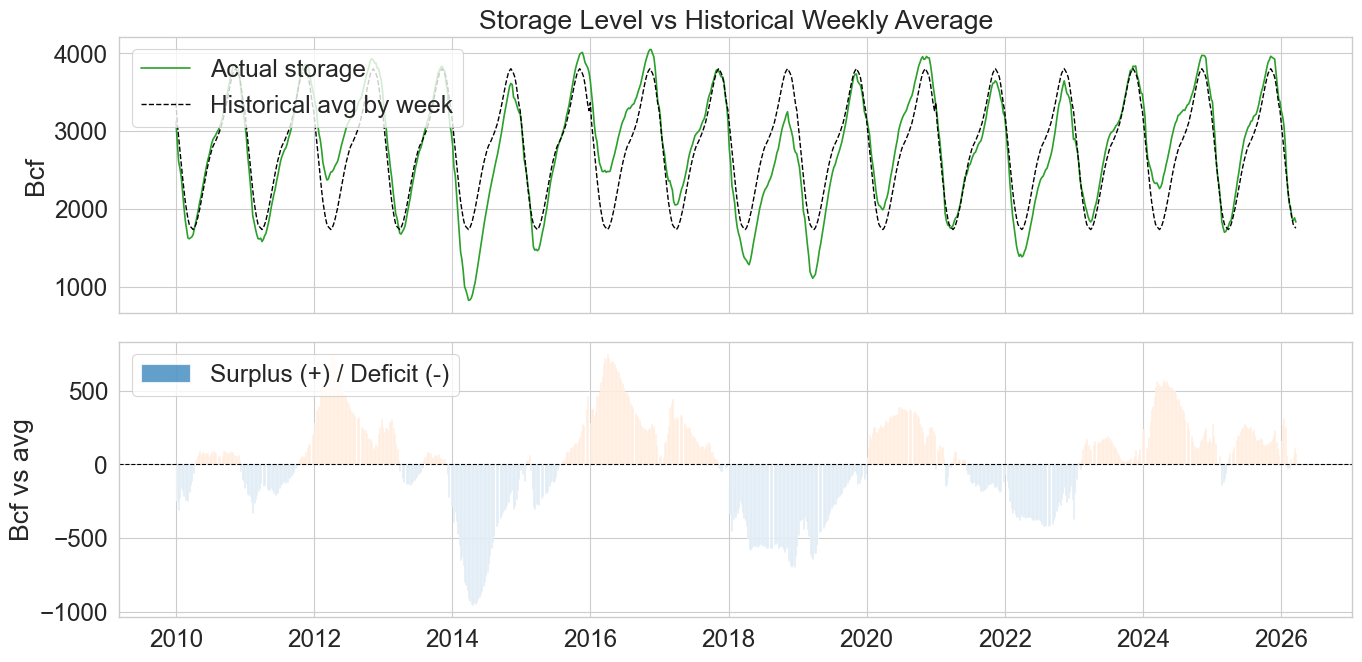

In [12]:
storage_df = storage.to_frame(name="storage_bcf")
storage_df["week"] = storage_df.index.isocalendar().week.astype(int)

# 5-year rolling average by week-of-year
five_yr_avg = storage_df.groupby("week")["storage_bcf"].transform(
    lambda x: x.rolling(5 * 52 // 52, min_periods=3).mean()
)

# Simpler: use the full-history mean by week as a proxy for the 5-year average
weekly_mean = storage_df.groupby("week")["storage_bcf"].mean()
storage_df["avg_bcf"] = storage_df["week"].map(weekly_mean)
storage_df["surplus_bcf"] = storage_df["storage_bcf"] - storage_df["avg_bcf"]

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(storage_df.index, storage_df["storage_bcf"], color="tab:green", linewidth=1.2, label="Actual storage")
axes[0].plot(storage_df.index, storage_df["avg_bcf"], color="black", linewidth=1.0, linestyle="--", label="Historical avg by week")
axes[0].set_ylabel("Bcf")
axes[0].set_title("Storage Level vs Historical Weekly Average")
axes[0].legend(loc="upper left")

axes[1].bar(
    storage_df.index,
    storage_df["surplus_bcf"],
    color=np.where(storage_df["surplus_bcf"] >= 0, "tab:orange", "tab:blue"),
    alpha=0.7,
    width=5,
    label="Surplus (+) / Deficit (-)",
)
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_ylabel("Bcf vs avg")
axes[1].set_xlabel("")
axes[1].legend(loc="upper left")

fig.tight_layout()
fig.savefig(DIAG / "storage_surplus_deficit.svg", format="svg", bbox_inches="tight")
plt.show()

## 6. Observations

### The storage cycle

US natural gas storage follows a predictable seasonal pattern:

- **Injection season (April–October):** Production exceeds demand (mild weather, low heating/cooling load). Gas is injected into underground storage — mostly depleted natural gas reservoirs and salt caverns. The market builds toward a ~3,500–3,900 Bcf peak by end-October
- **Withdrawal season (November–March):** Heating demand exceeds production. Storage is drawn down. The market watches the end-of-winter storage level closely — a low-inventory winter exit is bullish for the following summer's injection season

The seasonal average weekly change chart shows this cleanly: weeks 1–15 and 44–52 are net withdrawal weeks; weeks 16–43 are net injection weeks.

---

### Why the 5-year average comparison is the market's compass

The EIA report every Thursday at 10:30am ET includes the current storage level, the prior-year level, and the 5-year average for that week. The market immediately calculates the "storage surprise" — actual vs the analyst consensus build/draw estimate. A 20–30 Bcf surprise (in either direction) moves Henry Hub 3–5% within minutes.

The surplus/deficit chart shows the structural story:

- **2012 record surplus:** Warm winter of 2011–12, shale gas glut, record high storage of 3,929 Bcf. Henry Hub traded sub-$2.00 for months
- **2014 polar vortex:** Deep, sustained cold event — storage withdrew at an extreme rate. The inventory deficit entering spring was sharp and created a $6+ price spike
- **2019:** Record low end-of-injection inventory entering winter — persistent deficit through most of 2019 on cold weather and growing LNG exports
- **2020 COVID:** Demand destruction created a large surplus. Gas stayed cheap through 2020
- **2021 Uri:** One-week withdrawal event of ~340 Bcf — the largest weekly draw in the data. Showed storage can be drawn down extremely fast under the right conditions
- **2022 tight market:** Ukraine/LNG demand, Freeport outage, low storage entering winter — the full bearish trifecta created the sustained price spike to $8+

---

### Storage as a model feature

| Signal | Direction | Mechanism |
|---|---|---|
| Storage deficit vs 5-year avg | Bullish (↑ price) | Market prices in scarcity risk for next season |
| Storage surplus vs 5-year avg | Bearish (↓ price) | Cushion reduces supply risk premium |
| Low end-of-winter inventory | Bullish (↑ next summer injection demand) | High injection season demand → higher summer prices |
| Record high end-of-injection | Bearish | Market has full buffer entering winter, less weather risk premium |

Storage enters the model in two forms:
1. **Absolute level** (Bcf) — for seasonal context
2. **Surplus/deficit vs historical average** (Bcf deviation) — the market-relevant signal

The Thursday EIA release is the highest-frequency, highest-impact scheduled data event in US gas markets. Any model deployed in real-time must account for the weekly data update cadence.

---

### Storage-specific market structure

- **Storage capacity ceiling:** ~4,000 Bcf is the practical US storage capacity. When inventories approach that level in October, the market gets nervous — no more room to inject, production must be shut in or prices must fall to curtail supply. The 2012 record (3,929 Bcf) came close to a full-capacity event
- **Regional breakdown matters:** The EIA also publishes East, Midwest, Mountain, Pacific, and South Central storage. Regional imbalances (e.g. insufficient Northeast storage ahead of a cold snap) can spike basis differentials even when national storage looks healthy
- **Salt cavern vs depleted reservoir:** Salt caverns can inject/withdraw much faster — they are used to manage short-term peaks. Depleted reservoirs are slow, used for seasonal storage. The market structure of which storage type is being used matters for speed of response to weather events